# Q1

Why scale features before K-Means?
K-Means uses Euclidean distance to assign points to clusters. If features are on different scales (e.g., Age: 18–70, Annual Income: 15,000–140,000, Spending Score: 1–100), the feature with the largest numeric range (Income) will dominate the distance calculation, effectively drowning out the influence of Age and Spending Score. Scaling (e.g., StandardScaler) puts all features on a comparable scale (mean=0, std=1) so each contributes proportionally to the clustering, not just the one with the biggest raw numbers.

In [190]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [191]:
df=pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [192]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

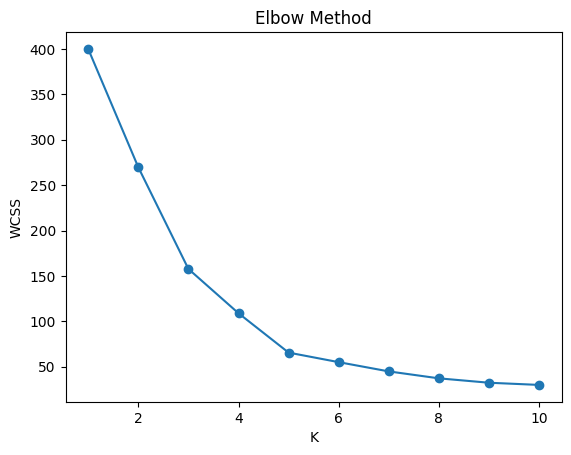

In [193]:
wcss=[]

for k in range(1,11):
  km=KMeans(n_clusters=k,random_state=42,n_init=10)
  km.fit(X_scaled)
  wcss.append(km.inertia_)


plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### from the graph it is clear that the elbow came at around 5. so its the optimal number of clusters. (WCSS drops sharply until K=5, then flattens out)

In [194]:
km5=KMeans(n_clusters=5,random_state=42,n_init=10)

df['Cluster']=km5.fit_predict(X_scaled)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [195]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [196]:
centers_scaled=km5.cluster_centers_
centers_scaled

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [197]:
centers=scaler.inverse_transform(centers_scaled)
centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [198]:
centers_df = pd.DataFrame(
    centers,
    columns=["Annual Income (k$)", "Spending Score"]
)
centers_df

,Annual Income (k$),Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [199]:
summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_counts=df['Cluster'].value_counts().sort_index()
summary['Count'] = cluster_counts
print("\nCluster summary:")
print(summary)


Cluster summary:
         Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                   
0                 55.296296               49.518519     81
1                 86.538462               82.128205     39
2                 25.727273               79.363636     22
3                 88.200000               17.114286     35
4                 26.304348               20.913043     23


### The High Income–High Spending cluster (around 86.5 income, 82.1 spending score) is the best target for luxury products because its members have both high purchasing power and a high tendency to spend.

# Q2

In [200]:
from sklearn.metrics import silhouette_score

In [201]:
df=pd.read_csv("/content/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [202]:
X=df.drop(['Id','Species'],axis=1)
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [203]:
scaler=StandardScaler()
scaled_x=scaler.fit_transform(X)

In [204]:
wcss = []
sil_scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_x)

    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_x,labels))

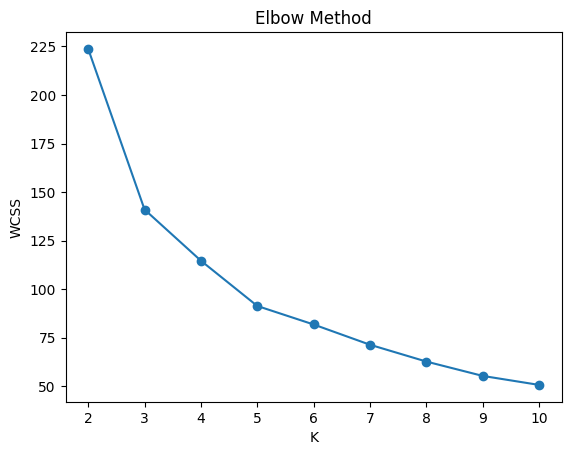

In [205]:
# Plot Elbow
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

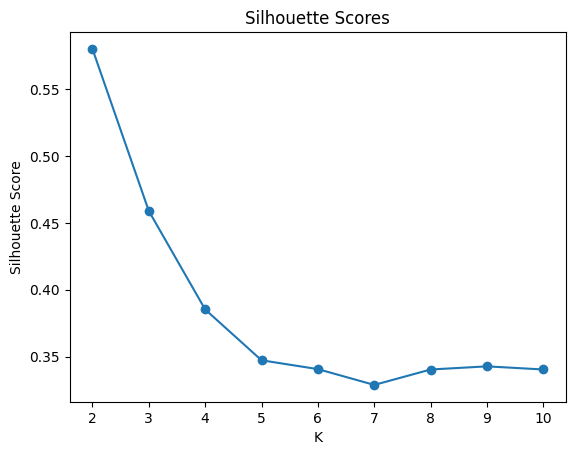

In [206]:
# Plot Silhouette
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

In [207]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_x)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,2
146,147,6.3,2.5,5.0,1.9,Iris-virginica,0
147,148,6.5,3.0,5.2,2.0,Iris-virginica,2
148,149,6.2,3.4,5.4,2.3,Iris-virginica,2


In [208]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nSamples per cluster:")
print(cluster_counts)


Samples per cluster:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [209]:
comparison = pd.crosstab(df['Species'], df['Cluster'])
print("\nSpecies vs Cluster crosstab:")
print(comparison)



Species vs Cluster crosstab:
Cluster           0   1   2
Species                    
Iris-setosa       0  50   0
Iris-versicolor  39   0  11
Iris-virginica   14   0  36


In [210]:
print("\nCluster vs Actual Species:")
print(pd.crosstab(df["Cluster"], df["Species"]))


Cluster vs Actual Species:
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               39              14
1                 50                0               0
2                  0               11              36


# Q4

In [211]:
import numpy as np
from sklearn.metrics import precision_score, recall_score,f1_score


In [212]:
df=pd.read_csv("/content/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [213]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [214]:
fraud_count = df['Class'].sum()
total_count = len(df)
fraud_pct = (fraud_count / total_count) * 100
print(f"\nTotal transactions: {total_count}")
print(f"Fraudulent transactions: {fraud_count}")
print(f"Fraud percentage: {fraud_pct:.4f}%")


Total transactions: 284807
Fraudulent transactions: 492
Fraud percentage: 0.1727%


In [215]:
X=df.drop('Class',axis=1)
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [216]:
scaler=StandardScaler()
Xscaled=scaler.fit_transform(X)

In [217]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(Xscaled)

KMeans(n_clusters=10, n_init=10, random_state=42)

In [218]:
distances = kmeans.transform(Xscaled)
nearest_distance = np.min(distances, axis=1)

In [219]:
threshold = np.percentile(nearest_distance, 95)
predicted = nearest_distance > threshold

print("Detected anomalies:", predicted.sum())

Detected anomalies: 14241


In [220]:
precision = precision_score(df["Class"], predicted)
recall = recall_score(df["Class"], predicted)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.030264728600519625
Recall: 0.8760162601626016


In [221]:
print(df.shape)
print(Xscaled.shape)
print(predicted.shape)
print(len(df["Class"]))

(284807, 31)
(284807, 30)
(284807,)
284807
